In [ ]:
!pip install -U transformers accelerate bitsandbytes peft datasets

In [ ]:
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get('HF_FINETUNE_TOKEN')
login(token=hf_token)

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
model_id = "google/gemma-3-270m-it"
tokenizer = AutoTokenizer.from_pretrained(model_id)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

In [ ]:
print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")
tokenizer("Shashinoor")

In [ ]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/FoodExtract-1k")

print(f"[INFO] Number of samples in the dataset: {len(dataset['train'])}")

In [ ]:
def format_input_to_instruction(input):
  template = {"role": "user", "content": input}
  return template

In [ ]:
from transformers import pipeline

In [ ]:
pipe = pipeline("text-generation",
                model=model,
                max_length=None,
                tokenizer=tokenizer)
text = "Hi my name is Daniel. Please reply to me with a machine learning poem."
input_text = format_input_to_instruction(text)
input_prompt = pipe.tokenizer.apply_chat_template([input_text], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)

default_outputs = pipe(input_prompt,
                       max_new_tokens=512,
                       disable_compile=True)

print(f"[INFO] Input:\n{input_prompt}")
print()
print(f"[INFO] Output from {model_id}:")
print()
print(default_outputs[0]["generated_text"][len(input_text):])

In [ ]:
!pip install trl

In [ ]:
from trl import SFTConfig

In [ ]:
torch_dtype = model.dtype

CHECKPOINT_DIR_NAME = "./checkpoint_models_v2"
BASE_LEARNING_RATE = 5e-5

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Using learning rate: {BASE_LEARNING_RATE}")

sft_config = SFTConfig(
    output_dir=CHECKPOINT_DIR_NAME,
    max_length=512,
    packing=False,
    num_train_epochs=2,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_checkpointing=False,
    optim="adamw_torch_fused", # Note: if you try "adamw", you will get an error
    logging_steps=1,
    save_strategy="epoch",
    eval_strategy="epoch",
    learning_rate=BASE_LEARNING_RATE,
    fp16=True if torch_dtype == torch.float16 else False,
    bf16=True if torch_dtype == torch.float16 else False,
    lr_scheduler_type="constant",
    push_to_hub=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2
)

[INFO] Using dtype: torch.bfloat16
[INFO] Using learning rate: 5e-05


In [ ]:
from trl import SFTTrainer

In [ ]:
def inject_messages(data):
  return {
        "messages": [
            {"role": "user", "content": data["sequence"]}, # Load the sequence from the dataset
            {"role": "assistant", "content": data["gpt-oss-120b-label-condensed"]}
        ]
    }

In [ ]:
dataset = dataset.map(inject_messages,batched=False)
dataset = dataset["train"].train_test_split(test_size=0.2,
                                            shuffle=True,
                                            seed=42)

In [ ]:
dataset

In [ ]:
!nvidia-smi

In [ ]:
trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)


In [ ]:
trainer.train()

In [ ]:
trainer.save_model()

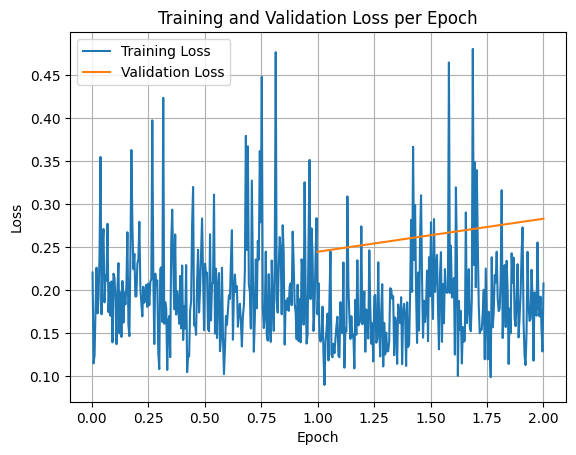

In [ ]:
import matplotlib.pyplot as plt

# Access the log history
log_history = trainer.state.log_history

# Extract training / validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss
plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load trained model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=CHECKPOINT_DIR_NAME,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
);

In [ ]:
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

loaded_model_pipeline

In [ ]:
dataset["test"]

In [ ]:
import random
def get_random_idx(dataset):
    """Returns a random integer index based on the number of samples in the dataset."""
    random_idx = random.randint(0, len(dataset)-1)
    return random_idx

In [ ]:
# Get a random sample
random_test_idx = get_random_idx(dataset["test"])
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_test_sample["messages"][:1],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input:\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")